In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from fenics import *
from pathlib import Path
from utils.metrics import vec_to_matrix, compute_cv_mask
from utils.mesh_utils import get_square_f, get_L_mesh, get_square_mesh
from utils.metrics import SpaceIndexing, error_centroid, error_movers, error_iou, error_ssim
from utils.metrics import rectangular_interpolation
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, tikhonov_solver, get_approximate_W
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit
from utils.metrics import SpaceIndexing
from utils.utils import progress_bar
from utils.colors import CMAP

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15

---
The experiments are performed on three problems:
 - Problem I (single source)
 - Problem II (triple source)
 - Problem III (double source, irregular grid)

In [21]:
n = 32
problem_params = {
    'I': {'mesh': get_square_mesh, 'n': n, 'width': 0.15, 'height': 0.15,
          'x0': [0.2], 'y0': [0.2]},
    'II': {'mesh': get_square_mesh, 'n': n, 'width': 0.15, 'height': 0.15,
           'x0': [0.1, 0.75, 0.15], 'y0': [0.1, 0.75, 0.70]},
    'III': {'mesh': get_L_mesh, 'n': n, 'width': 0.25, 'height': 0.25,
            'x0': [0.2, 1.55], 'y0': [0.2, 0.55]}
}

In [22]:
def get_source(V_h, x0_list, y0_list, width, height):
    x = np.zeros(V_h.dim())
    for x0, y0 in zip(x0_list, y0_list):
        f = get_square_f(V_h, x0=x0, y0=y0, w=width, h=height)
        x += f.vector().get_local()

    f = Function(V_h)
    f.vector()[:] = x
    return f, x


def problem_setup(params, lambda_):
    # Function space setup
    mesh = params['mesh'](params['n'])
    V_h = FunctionSpace(mesh, 'CG', 1)
    rsvd = MatrixFreeRSVD(V_h)

    # Source setup
    f, x = get_source(
        V_h, params['x0'], params['y0'], 
        params['width'], params['height']
    )
    y = rsvd.apply_K(x)

    # Full rank solution
    exact = ExactForwardOperator(V_h)
    f_hat = solve_explicit(operator=exact, w=exact.get_weights(), y=y, lambda_=lambda_)
    x_hat = f_hat.vector().get_local()

    problem = {'V_h': V_h, 'rsvd': rsvd, 'f': f, 'x': x, 'y': y, 'f_hat': f_hat, 'x_hat': x_hat}
    return problem


lambda_ = 1e-4
problems =  {}
for key, params in problem_params.items():
    pb = problem_setup(params, lambda_)
    print(f"Problem {key}: N_b={pb['rsvd'].N_b}, N={pb['rsvd'].N}")
    problems[key] = pb

Problem I: N_b=128, N=1089
Problem II: N_b=128, N=1089
Problem III: N_b=150, N=1588


../figures/problem_illustration.png already exists


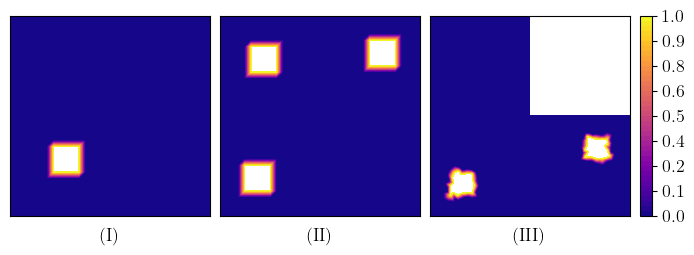

In [23]:
def save_plot(fig_name: str) -> None:
    if fig_name is not None:
        path = Path(f"../figures/{fig_name}.png")
        if not path.exists():
            plt.savefig(path, dpi=300, bbox_inches="tight")
        else:
            print(path, 'already exists')
    

def figure_problems(problems, fig_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))

    labels = ["(I)", "(II)", "(III)"]

    for ax, prob, label in zip(axes, ['I', 'II', 'III'], labels):
        f = problems[prob]['f']
        plt.sca(ax)
        p = plot(f, cmap=CMAP)

        ax.set_xticks([])
        ax.set_yticks([])

        ax.text(
            0.5, -0.057, label,
            transform=ax.transAxes,
            ha="center",
            va="top"
        )

    #fig.colorbar(p, ax=ax, location="right", format="%.2f", shrink=0.85)
    cax = fig.add_axes([0.913, 0.162, 0.015, 0.666]) # [left, bottom, width, height]
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    fig.colorbar(p, cax=cax, format="%.1f", norm=norm, shrink=0.8)
    #plt.subplots_adjust(wspace=0.07, right=0.9)

    #plt.tight_layout()
    plt.subplots_adjust(wspace=0.05)
    save_plot(fig_name)
    plt.show()


figure_problems(problems, fig_name='problem_illustration')

In [24]:
def relative_segmentation(x: np.ndarray, tau: float) -> np.ndarray:
    """Compute the relative threshold (fraction of max) segmentation."""
    return x >= tau * np.max(x)


def error_iou(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    """Intersection over Union between two binary masks."""
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    if union == 0:
        return 1.0
    return intersection / union


def error_auc_iou(
        x: np.ndarray, x_hat: np.ndarray, tau_range: np.ndarray = np.linspace(0.1, 1, 100)
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    x, np.array         : ground truth
    x_hat, np.array     : tikhonov solution
    tau_range, np.array : thresholds as fraction of max

    returns: (auc_iou, tau_max, ious)
    """
    ious = np.zeros(len(tau_range))

    for i, tau in enumerate(tau_range):
        mask = relative_segmentation(x, tau)
        mask_hat = relative_segmentation(x_hat, tau)
        ious[i] = error_iou(mask, mask_hat)

    return np.trapz(ious, tau_range), tau_range[np.argmax(ious)], ious

In [ ]:
def experiment_rsvd_over_k(
        problem: dict, k_range, p_list=None, repeat=1,
        lambda_=1e-4, rtol=1e-8
    ):
    rsvd: MatrixFreeRSVD = problem['rsvd']
    x = problem['x']
    y = problem['y']
    nk = len(k_range)

    if p_list is None:
        p_list = [5]

    records = []
    step = 0
    for p in p_list:
        for k in k_range:
            for r in range(repeat):
                step += 1

                # Solve inverse problem using matrix-free rSVD
                _, _, VT = rsvd.mf_rsvd(k=k, p=p, seed=SEED + r + p)
                w = get_approximate_W(VT.T, rsvd.M_dx)
                x_hat = tikhonov_solver(rsvd, w, y, lambda_=lambda_, rtol=rtol)

                # Compute masks for segmentation based metrics
                auc_iou, _, _ = error_auc_iou(x, x_hat)

                # Measure the error
                record = {
                    'p': p,
                    'k': k,
                    'repeat': r,
                    'euclidean': np.linalg.norm(x - x_hat),
                    'centroid': error_centroid(x, x_hat),
                    'emd': error_movers(x, x_hat),
                    'auc_iou': auc_iou,
                }

                records.append(record)
                progress_bar(step, len(p_list) * nk * repeat, end_text=f" [{p=},{k=}]")

    return pd.DataFrame(records)


def experiment_full_rank(problem: dict):
    V_h = problem['V_h']
    x = problem['x']
    f = problem['f']
    y = problem['y']

    exact = ExactForwardOperator(V_h)
    f_hat = solve_explicit(operator=exact, w=exact.get_weights(), y=y, lambda_=1e-4)
    x_hat = f_hat.vector().get_local()

    auc_iou, _, _ = error_auc_iou(x, x_hat)

    record_exact = {
        'euclidean': np.linalg.norm(x - x_hat),
        'centroid': error_centroid(x, x_hat),
        'emd': error_movers(x, x_hat),
        'auc_iou': auc_iou,
    }
    return pd.DataFrame([record_exact])

In [26]:
def plot_rsvd_over_k_2(df, df_exact):
    dists = ['Euclidean', 'EMD', 'IoU', 'SSIM']
    stats = df.groupby("k").agg(["mean", "std", "count"])

    fig, axes = plt.subplots(2, 2, sharex=True)
    axes = axes.flatten()

    repeat = max(df.repeat)
    for ax, dist in zip(axes, dists):

        for r in range(repeat):
            dfr = df[df.repeat == r]
            ax.plot(dfr.k, dfr[dist.lower()], c='b', alpha=.3)

        key = dist.lower()

        ax.axhline(df_exact[key][0], c='r', ls='--')
        ax.grid(alpha=.5)
        ax.set_title(dist)

    plt.tight_layout()


---
### Test problem I

In [27]:
def selected_solutions(problem: dict, k_list, lambda_=1e-4, p=5, rtol=1e-10):
    V_h = problem['V_h']
    y = problem['y']
    rsvd: MatrixFreeRSVD = problem['rsvd']

    # List of selected solutions
    f_selected = [problem['f_hat']]

    # Compute selected rank-k solutions
    for k in k_list:
        U, S, VT = rsvd.mf_rsvd(k=k, seed=SEED, p=p)
        w = get_approximate_W(VT.T, rsvd.M_dx)
        x_hat = tikhonov_solver(rsvd, w, y, lambda_=lambda_, rtol=rtol)
        f_hat = Function(V_h)
        f_hat.vector()[:] = x_hat
        f_selected.append(f_hat)

    return f_selected

In [28]:
def plot_solutions(f_list, params, fig_name=None):
    width = params['width']
    height = params['height']
    x0s, y0s = params['x0'], params['y0']

    import matplotlib.patches as patches

    fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True)
    axes = axes.flatten()

    # Global color scale
    #import matplotlib.colors as mcolors
    #vmin = min(fi.vector().min() for fi in f_list)
    #vmax = max(fi.vector().max() for fi in f_list)
    #norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for ax, fi in zip(axes, f_list):
        plt.sca(ax)
        p = plot(fi, cmap=CMAP) #, norm=norm)

        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(p, ax=ax, format="%.2f", shrink=0.655)

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)

    #fig.colorbar(p, ax=axes, format="%.2f", shrink=0.772, location='right', pad=0.0095)
    save_plot(fig_name)
    plt.show()

../figures/test_problem_I.png already exists


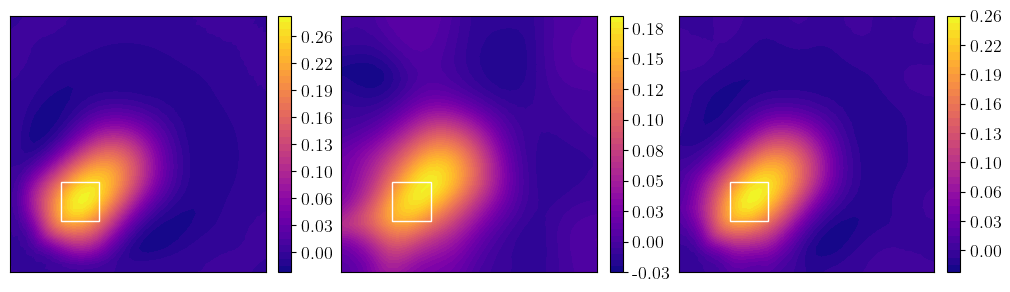

In [29]:
pb = 'I'

k_list = [10, 30]
f_selected = selected_solutions(problems[pb], k_list, p=5)
plot_solutions(f_selected, problem_params[pb], fig_name='test_problem_I')

In [35]:
k_range = np.arange(5, 110, 10)
p_list = [0, 5, 20]
repeat = 10

results = {}

df = experiment_rsvd_over_k(problems[pb], k_range, p_list, repeat)
df_fr = experiment_full_rank(problems[pb])

results[pb] = df.copy()
results[pb + '_fr'] = df_fr.copy()

[##############################] 330/330 [p=20,k=105]


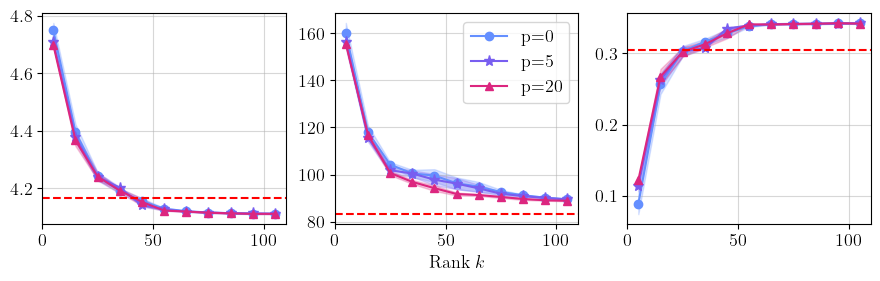

In [52]:
M = ['o', '*', '^', 's']
MS = [6, 8, 6, 6]


def plot_rsvd_over_k(results, pb, fig_name=None, title=True):
    from utils.colors import C3

    df = results[pb]
    df_fr = results[pb + '_fr']

    p_list = df.p.unique()
    stats = df.groupby(["p", "k"]).agg(["mean", "std", "count"])

    fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True)
    axes = axes.flatten()

    dists = ['euclidean', 'emd', 'auc_iou']
    titles = {'euclidean': 'Euclidean', 'emd': 'EMD', 'auc_iou': 'AUC-IoU'}

    for ax, dist in zip(axes, dists):
        key = dist.lower()

        for i, p in enumerate(p_list):
            stats_p = stats.loc[p]

            # 95% CI
            mean = stats_p[(key, "mean")]
            std = stats_p[(key, "std")]
            n = stats_p[(key, "count")]
            ci95 = 1.96 * std / np.sqrt(n)

            k_vals = mean.index
            ax.plot(k_vals, mean, label=f'{p=}', c=C3[i], marker=M[i], ms=MS[i])
            ax.fill_between(k_vals, mean - ci95, mean + ci95, alpha=0.25, color=C3[i])

        ax.axhline(df_fr[key][0], c='r', ls='--')

        ax.grid(alpha=.5)
        if title: ax.set_title(titles[dist])

    axes[1].set_xlabel("Rank $k$")
    axes[1].legend()
    #axes[1].legend(loc='upper right', ncols=3, bbox_to_anchor=(1.25, -0.3), fontsize=13)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.2)
    save_plot(fig_name)
    plt.show()


plot_rsvd_over_k(results, pb='I', fig_name='rsvd_over_k_I', title=False)

In [37]:
def save_results(results):
    result_dir = Path("../results")

    for name, df in results.items():
        file_path = result_dir / f"13_{name}.csv"
        if not file_path.exists():
            print(f"Saving {file_path}")
            df.to_csv(file_path)


save_results(results)

---
### Test problem II

../figures/test_problem_II.png already exists


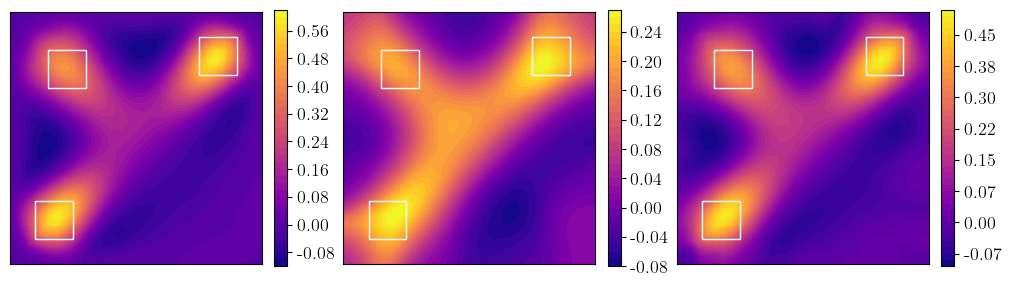

In [38]:
pb = 'II'

k_list = [10, 30]
f_selected = selected_solutions(problems[pb], k_list, p=5)
plot_solutions(f_selected, problem_params[pb], fig_name='test_problem_II')

In [39]:
k_range = np.arange(5, 110, 10)
p_list = [0, 5, 20]
repeat = 10

df = experiment_rsvd_over_k(problems[pb], k_range, p_list, repeat)
df_fr = experiment_full_rank(problems[pb])

results[pb] = df.copy()
results[pb + '_fr'] = df_fr.copy()

[##############################] 330/330 [p=20,k=105]


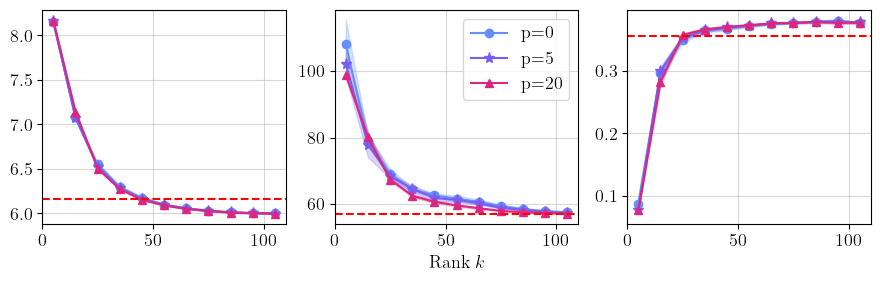

In [53]:
plot_rsvd_over_k(results, pb='II', fig_name='rsvd_over_k_II', title=False)

---
### Test problem III

../figures/test_problem_III.png already exists


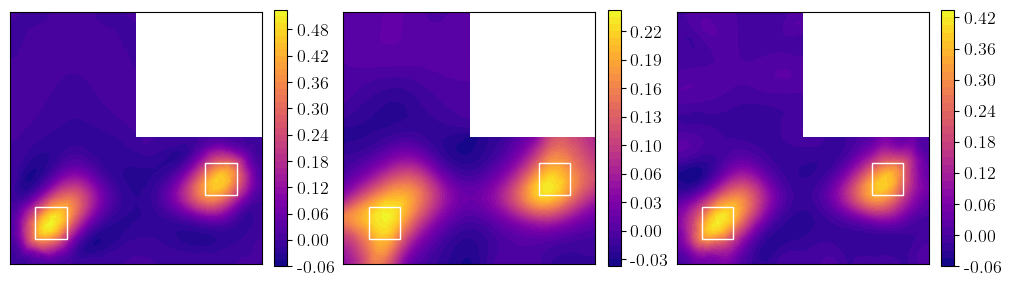

In [45]:
pb = 'III'

k_list = [10, 30]
f_selected = selected_solutions(problems[pb], k_list, p=5, rtol=1e-12)
plot_solutions(f_selected, problem_params[pb], fig_name='test_problem_III')

In [46]:
k_range = np.arange(5, 110, 10)
p_list = [0, 5, 20]
repeat = 5

df = experiment_rsvd_over_k(problems[pb], k_range, p_list, repeat, irregular=True, rtol=1e-12)
df_fr = experiment_full_rank(problems[pb], irregular=True)

[##############################] 165/165 [p=20,k=105]


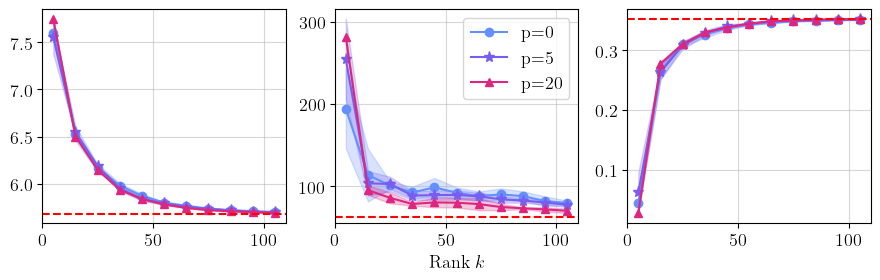

In [54]:
results[pb] = df.copy()
results[pb + '_fr'] = df_fr.copy()

plot_rsvd_over_k(results, pb='III', fig_name='rsvd_over_k_III', title=False)